# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('C:/Users/parva/Downloads/1750862181_Frequentist_Inference_Case_Study_-_Part_B/Frequentist Inference Case Study - Part B/insurance2.csv')

In [23]:
medical.shape

(1338, 8)

In [24]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

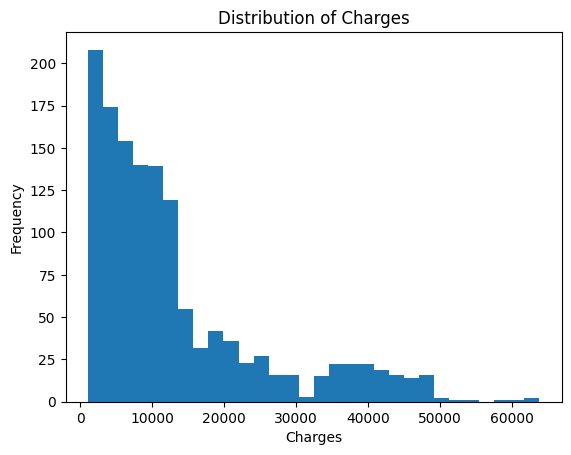

In [25]:
plt.hist(medical['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

In [26]:
mean_charges = medical['charges'].mean()
std_charges = medical['charges'].std()

In [27]:
mean_charges

np.float64(13270.422265141257)

In [28]:
std_charges

12110.011236693994

The mean is sensitive to unusually high charges, and the standard deviation is also affected by these extreme values. In this case, the median and interquartile range (IQR) would provide more robust measures of the center and spread.

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ Since we are assuming that these data represent a random sample of hospital charges, we can use the sample to make inferences about the population of all hospital charges. The sample mean therefore provides an estimate of the population mean, and the Central Limit Theorem allows us to use the sampling distribution of the mean for inference, particularly because the sample is sufficiently large.

The administrator's concern is whether the actual average charge has fallen below $12,000. Therefore, the hypotheses are:

- **Null hypothesis:** $H_0: \mu = 12,000$
- **Alternative hypothesis:** $H_A: \mu < 12,000$

Because the population standard deviation is unknown and must be estimated from the sample, the most appropriate frequentist test is a **one-sample, one-tailed t-test**. The test will determine whether there is sufficient statistical evidence to conclude that the population mean charge is less than $12,000.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__

A **one-sided 95% confidence interval** is appropriate because the administrator is specifically concerned about whether the true population mean charge has fallen **below $12,000**. We are therefore interested only in the lower bound of the confidence interval.

Using the sample standard deviation to estimate the population standard deviation, we calculate the critical value from the $t$ distribution with $n-1$ degrees of freedom. The resulting one-sided 95% confidence interval is $[L, \infty)$, where $L$ is the calculated lower confidence bound.

If the lower confidence bound is **above \$12,000**, we have evidence that the true mean charge is greater than $12,000, so the administrator should not be concerned.

If the lower confidence bound is **below \$12,000**, the data do not provide sufficient evidence to rule out a population mean below $12,000. Therefore, the administrator's concern cannot be dismissed based on this sample alone.

In [29]:
# sample size
n = len(medical['charges'])
n

1338

In [30]:
# sample mean of the medical charges
mean = medical['charges'].mean()
mean

np.float64(13270.422265141257)

In [31]:
# sample standard deviation
std = medical['charges'].std()
std

12110.011236693994

In [32]:
# degrees of freedom
dfree = n - 1
dfree

1337

In [33]:
import scipy.stats as stats
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha, dfree)
t_critical

np.float64(1.6459941145571317)

In [34]:
lower_bound = mean - t_critical * (std / np.sqrt(n))
lower_bound

np.float64(12725.48718381623)

#### The confidence interval indicates that the true mean charge is likely above $12,000, so the administrator should not be concerned based on this sample.

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ 

We want to determine whether the mean charge is different for people with insurance compared with those without insurance.

- **Null hypothesis:** $H_0: \mu_0 = \mu_1$  
  There is no difference in the mean charges between the two groups.

- **Alternative hypothesis:** $H_A: \mu_0 \neq \mu_1$  
  There is a difference in the mean charges between the two groups.

Since this is a two-sided test, we are interested in whether the mean charges differ in either direction.

The pooled standard deviation assumes that the **population variances of the two groups are equal**. In other words, we assume that the variability in charges is approximately the same for people with insurance and those without insurance. 

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [35]:
# two independent groups
charges_0 = medical[medical['insuranceclaim'] == 0]['charges']
charges_1 = medical[medical['insuranceclaim'] == 1]['charges']

In [36]:
# sample sizes
n0 = len(charges_0)
n1 = len(charges_1)

In [37]:
# sample means
mean_0 = charges_0.mean()
mean_1 = charges_1.mean()

In [38]:
# sample standard deviations
s0 = charges_0.std()
s1 = charges_1.std()

In [39]:
# pooled standard deviation
sp = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2)/ (n0 + n1 - 2))
sp

np.float64(11520.034268775256)

In [40]:
# t-test statistic
t_stat = (mean_0 - mean_1) / (sp * np.sqrt(1/n0 + 1/n1))
t_stat

np.float64(-11.893299030876715)

In [41]:
# degrees of freedom
dfree = n0 + n1 - 2
dfree

1336

In [42]:
# two-sided p-value
import scipy.stats as stats
p_value = 2 * stats.t.sf(abs(t_stat), dfree)
p_value

np.float64(4.4612302316205886e-31)

#### same test using scipy.stats

In [43]:
t_stat_scipy, p_value_scipy = stats.ttest_ind(
    charges_0,
    charges_1,
    equal_var=True
)

print("t-statistic:", t_stat_scipy)
print("p-value:", p_value_scipy)

t-statistic: -11.893299030876712
p-value: 4.461230231620717e-31


In [44]:
t_stat_scipy

np.float64(-11.893299030876712)

In [45]:
t_stat

np.float64(-11.893299030876715)

In [46]:
p_value_scipy

np.float64(4.461230231620717e-31)

In [47]:
p_value

np.float64(4.4612302316205886e-31)

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ There is no dedicated function for a z-test. This is because a z-test is generally used when the population standard deviation is known, whereas in most practical situations the population standard deviation is unknown and must be estimated from the sample. In that case, a t-test is more appropriate.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test